# Block 1 — Deep Learning with Time Series Data: Preprocessing Fundamentals

**Goals for this block:**
- Load and analyze time series datasets
- Implement effective strategies for handling missing values
- Normalize and standardize features for optimal model performance
- Create proper time-aware train/validation/test splits
- Generate sliding windows for sequence modeling

## 0. Setup & Environment

Let's import the necessary libraries for time series analysis and visualization.

In [1]:
# GUIDED: imports and environment checks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

## 1. Data Loading and Initial Exploration

We'll work with an **energy generation** dataset that contains typical patterns and challenges found in real-world time series data.

In [2]:
# GUIDED: load data
df = pd.read_csv("energy_synthetic.csv")
# parse a timestamp column smartly
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True, errors='coerce')
df['timestamp'] = df['timestamp'].dt.tz_localize(None)
df = df.set_index('timestamp').sort_index()
df.head(6)

,value
timestamp,
2022-01-01 00:00:00,51.694168
2022-01-01 01:00:00,51.868224
2022-01-01 02:00:00,NaN
2022-01-01 03:00:00,55.978375
2022-01-01 04:00:00,59.958977
2022-01-01 05:00:00,60.526610


### 1.1 Data Quality Checks

Before preprocessing, we need to verify several important properties:
- **Index integrity**: Is the index properly formatted as a DatetimeIndex and monotonically increasing?
- **Frequency detection**: Can we detect the native sampling frequency of the data?
- **Data completeness**: Are there missing values or duplicate timestamps that need handling?

In [3]:
# GUIDED: basic info
print(df.info())

# Check duplicates
dups = df.index.duplicated().sum()
print(f'Duplicate timestamps: {dups}')

# infer frequency
inferred = pd.infer_freq(df.index)
print('Inferred frequency:', inferred)

# Check missing
missing = df.isna().sum()
print('Missing values per column:\n', missing)


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 17520 entries, 2022-01-01 00:00:00 to 2023-12-31 23:00:00
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   value   15357 non-null  float64
dtypes: float64(1)
memory usage: 273.8 KB
None
Duplicate timestamps: 0
Inferred frequency: h
Missing values per column:
 value    2163
dtype: int64


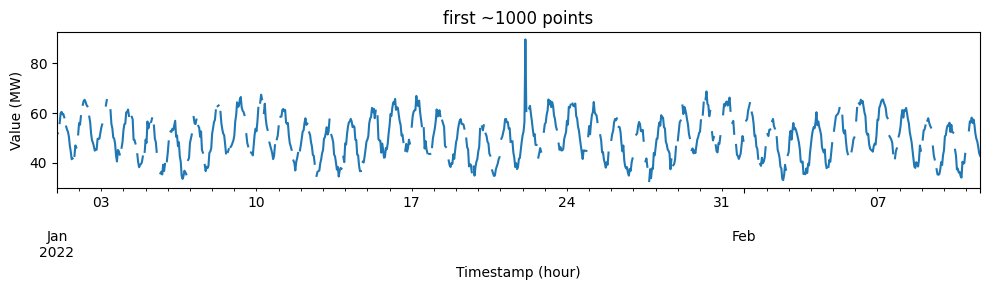

In [4]:
# GUIDED: visualize raw series
plt.figure(figsize=(10, 3))
df.iloc[:1000, 0].plot(title='first ~1000 points', xlabel='Timestamp (hour)', ylabel='Value (MW)')
plt.tight_layout()
plt.show()

## 2. Handling Missing Values in Time Series

Missing values in time series require special attention as they can affect temporal patterns. The appropriate strategy depends on your domain knowledge and the characteristics of the data:

- **Forward-fill**: Propagates the last valid observation forward (assumes persistence)
- **Backward-fill**: Uses next known values to fill gaps (useful for backfilling historical data)
- **Interpolation**: Creates smooth transitions between known values (linear, polynomial)

The choice should reflect the underlying physical or business process generating the data.

In [5]:
print('Missing values per column:\n', missing)

Missing values per column:
 value    2163
dtype: int64


In [6]:
# GUIDED: choose a missing value strategy and apply it
# TODO: Replace 'method' / 'limit' as needed or implement interpolation

filled = df.copy()

# Example 1: linear-based interpolation
# filled = filled.interpolate(method='linear')

# Example 2: forward/backward fill
filled = filled.ffill().bfill()

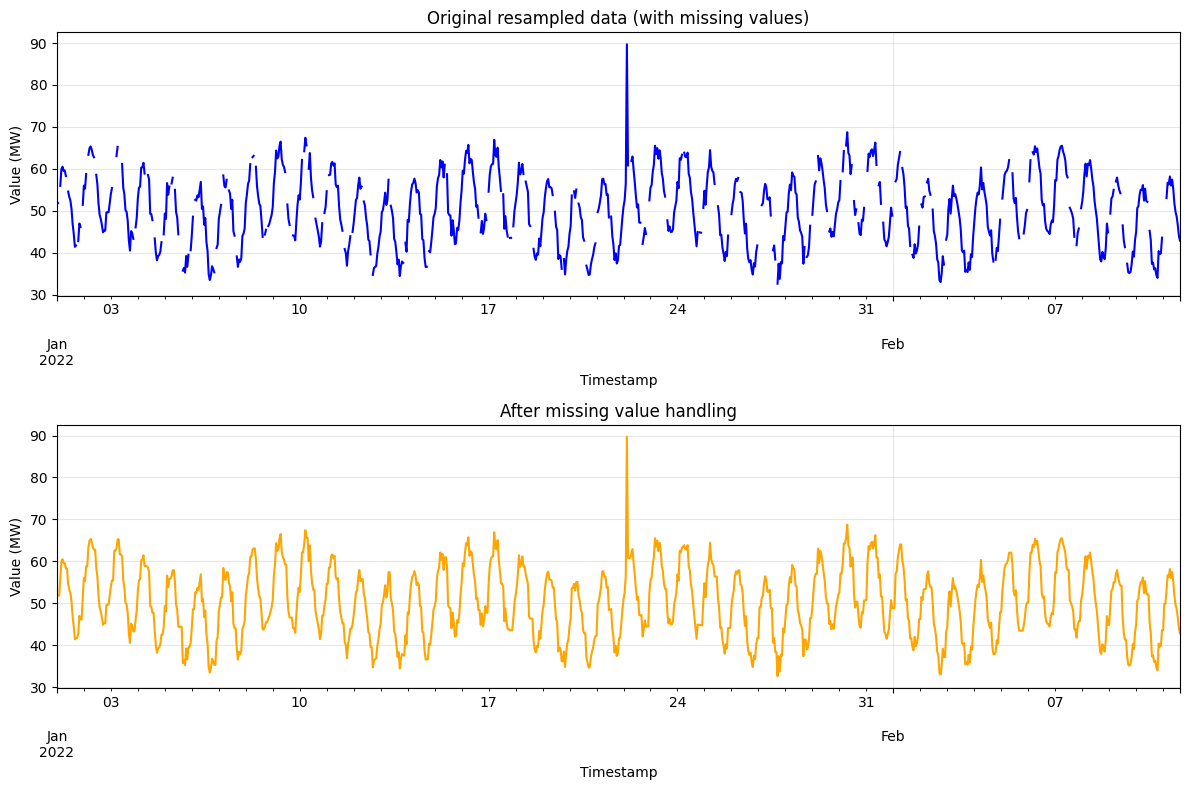

In [7]:
# EXERCISE: Compare filled vs non-filled data in subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot original resampled data (with missing values)
df.iloc[:1000, 0].plot(ax=ax1, title='Original resampled data (with missing values)', 
                               xlabel='Timestamp', ylabel='Value (MW)', color='blue')
ax1.grid(True, alpha=0.3)

# Plot filled data
filled.iloc[:1000, 0].plot(ax=ax2, title='After missing value handling', 
                           xlabel='Timestamp', ylabel='Value (MW)', color='orange')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
# GUIDED: Check now many missing values remain
print('Missing values per column:\n', filled.isna().sum())

Missing values per column:
 value    0
dtype: int64


## 3. Resampling Time Series Data

**Goal:** Transform irregular or high-frequency data into a consistent, regular time grid.

### Why Resampling Matters:
- Creates uniform time steps for modeling algorithms
- Reduces noise through aggregation
- Aligns data with business/analysis timeframes (hourly, daily, weekly)

### Key Considerations:
1. Detect the original (native) sampling frequency
2. Choose an appropriate target frequency (hourly, daily, etc.)
3. Select the right aggregation method:
   - **Mean**: For measurements representing instantaneous values
   - **Sum**: For cumulative values that should be added (e.g., energy production)
   - **Last/First**: For snapshots or state-based values

In [9]:
# GUIDED: Resampling

TARGET_FREQ = 'D'  # e.g., 'H' hourly, 'D' daily, 'M' monthly
AGG = 'mean'       # domain-dependent; 'sum' might be better for energy if values are power vs. energy

if AGG == 'mean':
    resampled = filled.resample(TARGET_FREQ).mean()
elif AGG == 'sum':
    resampled = filled.resample(TARGET_FREQ).sum()
elif AGG == 'last':
    resampled = filled.resample(TARGET_FREQ).last()
else:
    raise ValueError('Unsupported aggregation')

resampled.head(3)

,value
timestamp,
2022-01-01,51.190721
2022-01-02,55.136320
2022-01-03,53.327051


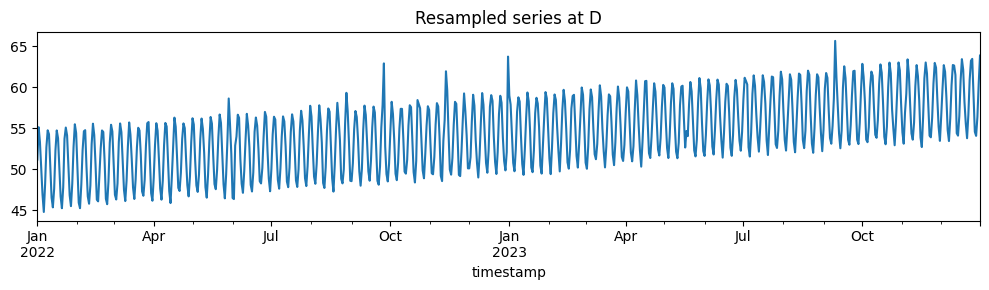

In [10]:
# GUIDED: visualize resampled series
plt.figure(figsize=(10, 3))
resampled.iloc[:1000, 0].plot(title=f'Resampled series at {TARGET_FREQ}')
plt.tight_layout()
plt.show()

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Data Preparation</h2>

Complete the following tasks with the `electricity.csv` dataset:
1. Load and visualize the raw data
2. Identify and handle missing values 
   - Try different filling methods (e.g., ffill, bfill, interpolate)

3. Resample the data to a suitable frequency
   - Try different resampling frequencies (e.g., hourly vs. daily)


This exercise will help reinforce the concepts of data cleaning and preparation for time series.
</div>

In [11]:
# Load exercise data

df_excercise = pd.read_csv("electricity.csv")
#df_excercise['timestamp'] = ...

df_excercise['timestamp'] = pd.to_datetime(df_excercise['timestamp'], utc=True, errors='coerce')
df_excercise['timestamp'] = df_excercise['timestamp'].dt.tz_localize(None)
df_excercise = df_excercise.set_index('timestamp').sort_index()


In [12]:
df_excercise

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_091,MT_092,MT_093,MT_094,MT_095,MT_096,MT_097,MT_098,MT_099,MT_100
timestamp,,,,,,,,,,,,,,,,,,,,,
2012-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
2012-01-01 00:15:00,3.807107,22.759602,77.324066,136.178862,70.731707,351.190476,9.609949,279.461279,75.174825,87.096774,...,108.739159,0.000000,2.030457,10.106114,4.714510,8.695652,98.739496,224.052718,335.93750,13.315579
2012-01-01 00:30:00,5.076142,22.759602,77.324066,136.178862,73.170732,354.166667,9.044658,279.461279,73.426573,84.946237,...,94.062708,0.000000,2.030457,9.600808,3.666841,9.275362,98.739496,222.405272,281.25000,11.984021
2012-01-01 00:45:00,3.807107,22.759602,77.324066,140.243902,69.512195,348.214286,8.479367,279.461279,75.174825,91.397849,...,153.435624,0.000000,2.030457,8.084891,3.666841,8.115942,96.638655,209.225700,261.71875,11.318242
2012-01-01 01:00:00,3.807107,22.759602,77.324066,140.243902,75.609756,339.285714,7.348785,279.461279,68.181818,88.172043,...,156.771181,0.000000,2.030457,8.084891,3.666841,11.014493,98.739496,205.930807,261.71875,11.318242
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,72.043011,...,101.400934,32.191070,2.538071,16.675088,13.619696,11.014493,92.436975,308.072488,406.25000,10.652463
2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,72.043011,...,100.733823,31.671859,2.538071,16.169783,3.666841,8.115942,88.235294,309.719934,394.53125,8.655126
2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,74.193548,...,102.735157,30.633437,2.538071,16.169783,2.619172,7.536232,94.537815,308.072488,375.00000,8.655126


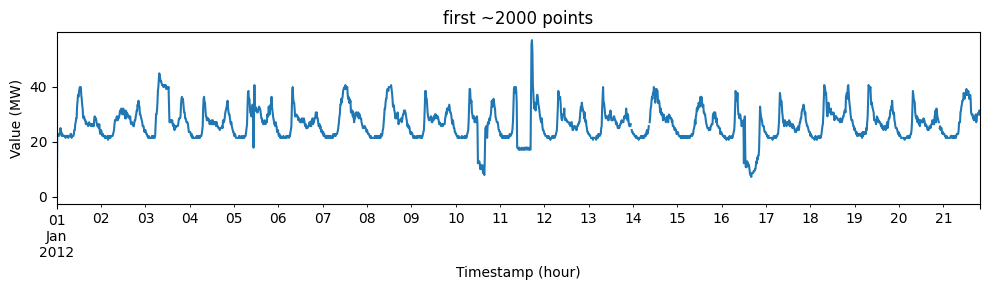

In [13]:
# GUIDED: visualize raw series: try differrent households "MT_001", "MT_002", ..., 

plt.figure(figsize=(10, 3))
df_excercise["MT_002"].iloc[:2000].plot(title='first ~2000 points', xlabel='Timestamp (hour)', ylabel='Value (MW)')
plt.tight_layout()
plt.show()

In [14]:
# Check missing values

print('Missing values per column:\n', df_excercise.isna().sum())

Missing values per column:
 MT_001    1066
MT_002    1066
MT_003    1066
MT_004    1066
MT_005    1066
          ... 
MT_096    1066
MT_097    1066
MT_098    1066
MT_099    1066
MT_100    1066
Length: 100, dtype: int64


In [15]:
# handle missing values

filled_exercise = df_excercise.copy()

filled_exercise = filled_exercise.interpolate(method='linear')

In [16]:
print('Missing values per column:\n', filled_exercise.isna().sum())

Missing values per column:
 MT_001    0
MT_002    0
MT_003    0
MT_004    0
MT_005    0
         ..
MT_096    0
MT_097    0
MT_098    0
MT_099    0
MT_100    0
Length: 100, dtype: int64


In [17]:
# Resampling: try frequency "D", "h", "W"

resampled_exercise = filled_exercise.resample("D").sum()


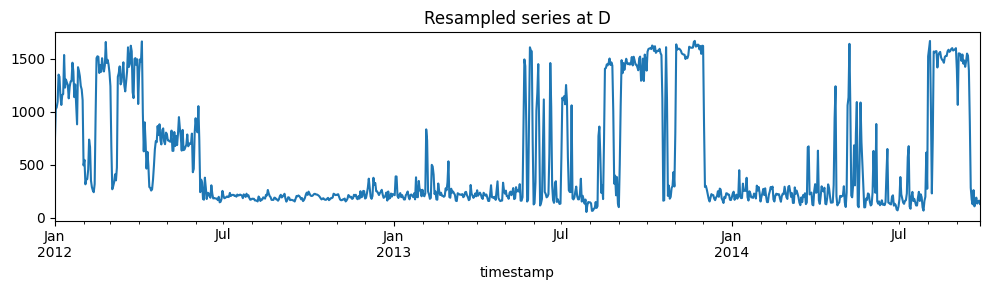

In [18]:
plt.figure(figsize=(10, 3))
resampled_exercise["MT_001"].iloc[:1000].plot(title=f'Resampled series at {"D"}')
plt.tight_layout()
plt.show()

## 4. Feature Scaling for Time Series

Proper scaling is essential for many machine learning algorithms to work effectively with time series data.

### Common Scaling Techniques:
- **Z-score (StandardScaler)**: `(x - mean) / std` - Centers data around zero with unit variance
- **Min-Max (MinMaxScaler)**: Scales data to a fixed range [0, 1]
- **Robust Scaler**: Uses median and IQR, making it resistant to outliers

### ⚠️ Important: Avoid Data Leakage
Always fit scalers **only on training data** to prevent information leakage from the validation and test sets. The code below demonstrates the effect of scaling but should not be applied to the entire dataset in a real forecasting scenario.

In [19]:
# GUIDED: Experiment with different scaling methods
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# Uncomment ONE of the following scaling methods to see how they affect the data:

# Option 1: Z-Score (Standard) Scaling - normalizes to mean=0, std=1
# rescaled = pd.DataFrame(StandardScaler().fit_transform(resampled.values), 
#                                index=resampled.index, columns=resampled.columns)

# Option 2: MinMax Scaling - scales to range [0, 1]
# rescaled = pd.DataFrame(MinMaxScaler().fit_transform(resampled.values), 
#                                index=resampled.index, columns=resampled.columns)

# Option 3: Robust Scaling - uses median and IQR, less sensitive to outliers
rescaled = pd.DataFrame(RobustScaler().fit_transform(resampled.values), 
                               index=resampled.index, columns=resampled.columns)


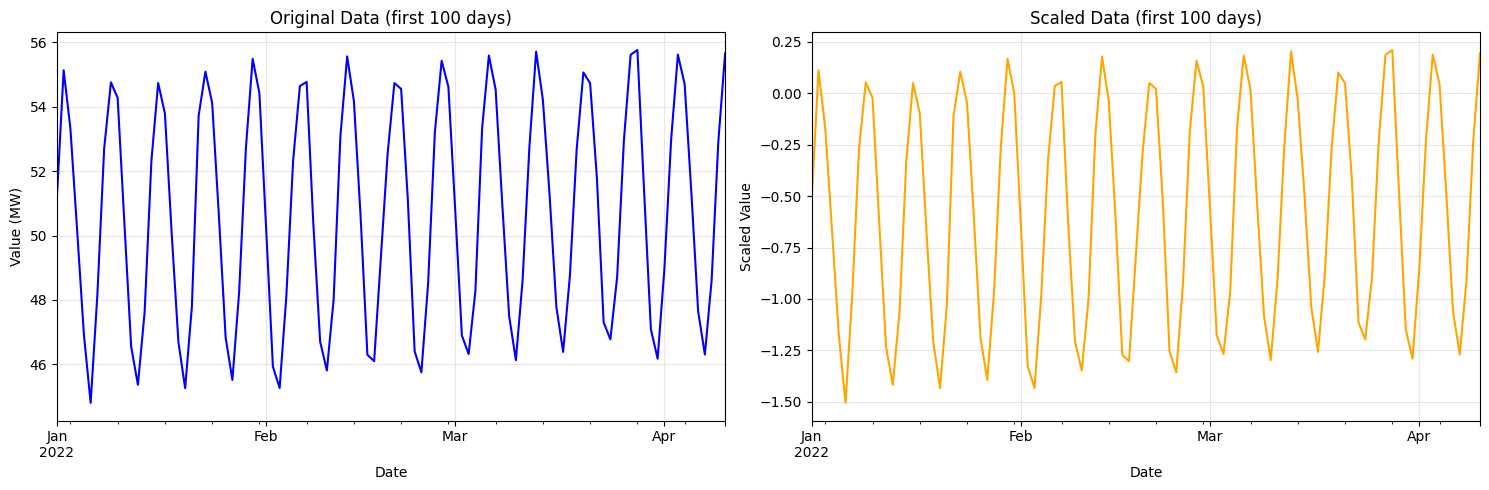

In [20]:
# Visualize the effects of scaling
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Original data
resampled.iloc[:100, 0].plot(ax=ax1, title='Original Data (first 100 days)', 
                            xlabel='Date', ylabel='Value (MW)', color='blue')
ax1.grid(True, alpha=0.3)

# Scaled data
rescaled.iloc[:100, 0].plot(ax=ax2, title='Scaled Data (first 100 days)', 
                              xlabel='Date', ylabel='Scaled Value', color='orange')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [21]:
# GUIDED: Define functions for training/validation/test scaling
def scale_using_zscore(train_df, val_df, test_df):
    """
    Apply Z-Score (Standard) scaling: (x - mean) / std
    Returns: train_scaled, val_scaled, test_scaled, scaler
    """
    scaler = StandardScaler()
    scaler.fit(train_df.values)
    
    train_scaled = pd.DataFrame(scaler.transform(train_df.values), 
                               index=train_df.index, columns=train_df.columns)
    val_scaled = pd.DataFrame(scaler.transform(val_df.values), 
                             index=val_df.index, columns=val_df.columns)
    test_scaled = pd.DataFrame(scaler.transform(test_df.values), 
                              index=test_df.index, columns=test_df.columns)
    
    return train_scaled, val_scaled, test_scaled, scaler

def scale_using_minmax(train_df, val_df, test_df):
    """
    Apply MinMax scaling: (x - min) / (max - min) -> [0, 1]
    Returns: train_scaled, val_scaled, test_scaled, scaler
    """
    scaler = MinMaxScaler()
    scaler.fit(train_df.values)
    
    train_scaled = pd.DataFrame(scaler.transform(train_df.values), 
                               index=train_df.index, columns=train_df.columns)
    val_scaled = pd.DataFrame(scaler.transform(val_df.values), 
                             index=val_df.index, columns=val_df.columns)
    test_scaled = pd.DataFrame(scaler.transform(test_df.values), 
                              index=test_df.index, columns=test_df.columns)
    
    return train_scaled, val_scaled, test_scaled, scaler

def scale_using_robust(train_df, val_df, test_df):
    """
    Apply Robust scaling: (x - median) / IQR
    Less sensitive to outliers than StandardScaler
    Returns: train_scaled, val_scaled, test_scaled, scaler
    """
    scaler = RobustScaler()
    scaler.fit(train_df.values)
    
    train_scaled = pd.DataFrame(scaler.transform(train_df.values), 
                               index=train_df.index, columns=train_df.columns)
    val_scaled = pd.DataFrame(scaler.transform(val_df.values), 
                             index=val_df.index, columns=val_df.columns)
    test_scaled = pd.DataFrame(scaler.transform(test_df.values), 
                              index=test_df.index, columns=test_df.columns)
    
    return train_scaled, val_scaled, test_scaled, scaler

def print_scaling_stats(train_scaled, val_scaled, test_scaled, method_name):
    """Print statistics for scaled datasets"""
    print(f"\n{method_name} Scaling Statistics:")
    print(f"Train - Mean: {train_scaled.mean().values[0]:.6f}, Std: {train_scaled.std().values[0]:.6f}")
    print(f"Val   - Mean: {val_scaled.mean().values[0]:.6f}, Std: {val_scaled.std().values[0]:.6f}")
    print(f"Test  - Mean: {test_scaled.mean().values[0]:.6f}, Std: {test_scaled.std().values[0]:.6f}")

## 5. Time-Aware Data Splitting

Unlike traditional random splits used in other ML tasks, time series data requires **chronological splitting** to preserve temporal dependencies and avoid look-ahead bias.

### Common Splitting Strategies:
- **Hold-Out Split**: Simple chronological division (e.g., 70% train, 15% validation, 15% test)
- **Rolling Window**: Multiple train/test splits that move forward in time
- **Expanding Window**: Growing training set with a rolling evaluation window

For this introductory block, we'll implement a basic Hold-Out split to establish the foundation for more advanced techniques.

In [22]:
# GUIDED: chronological split

len_train = int(len(resampled) * 0.7)
len_val = int(len(resampled) * 0.15)

train = resampled.iloc[:len_train]
val = resampled.iloc[len_train:len_train+len_val]
test = resampled.iloc[len_train+len_val:]

print('Split sizes:', len(train), len(val), len(test))
print('Ranges:')
print('Train:', train.index.min(), '→', train.index.max())
print('Val  :', val.index.min(),   '→', val.index.max())
print('Test :', test.index.min(),  '→', test.index.max())

Split sizes: 510 109 111
Ranges:
Train: 2022-01-01 00:00:00 → 2023-05-25 00:00:00
Val  : 2023-05-26 00:00:00 → 2023-09-11 00:00:00
Test : 2023-09-12 00:00:00 → 2023-12-31 00:00:00


In [23]:
# GUIDED: Choose and apply scaling method
# Uncomment ONE of the following scaling methods:

# Option 1: Z-Score (Standard) Scaling
train_s, val_s, test_s, SCALER = scale_using_zscore(train, val, test)

# Option 2: MinMax Scaling
# train_s, val_s, test_s, SCALER = scale_using_minmax(train, val, test)
# print_scaling_stats(train_s, val_s, test_s, "MinMax")

# Option 3: Robust Scaling
# train_s, val_s, test_s, SCALER = scale_using_robust(train, val, test)
# print_scaling_stats(train_s, val_s, test_s, "Robust")

train_s.head(3)

,value
timestamp,
2022-01-01,-0.493608
2022-01-02,0.516992
2022-01-03,0.053578



Z-Score Scaling Statistics:
Train - Mean: -0.000000, Std: 1.000982
Val   - Mean: 0.992055, Std: 0.895759
Test  - Mean: 1.273295, Std: 0.895869


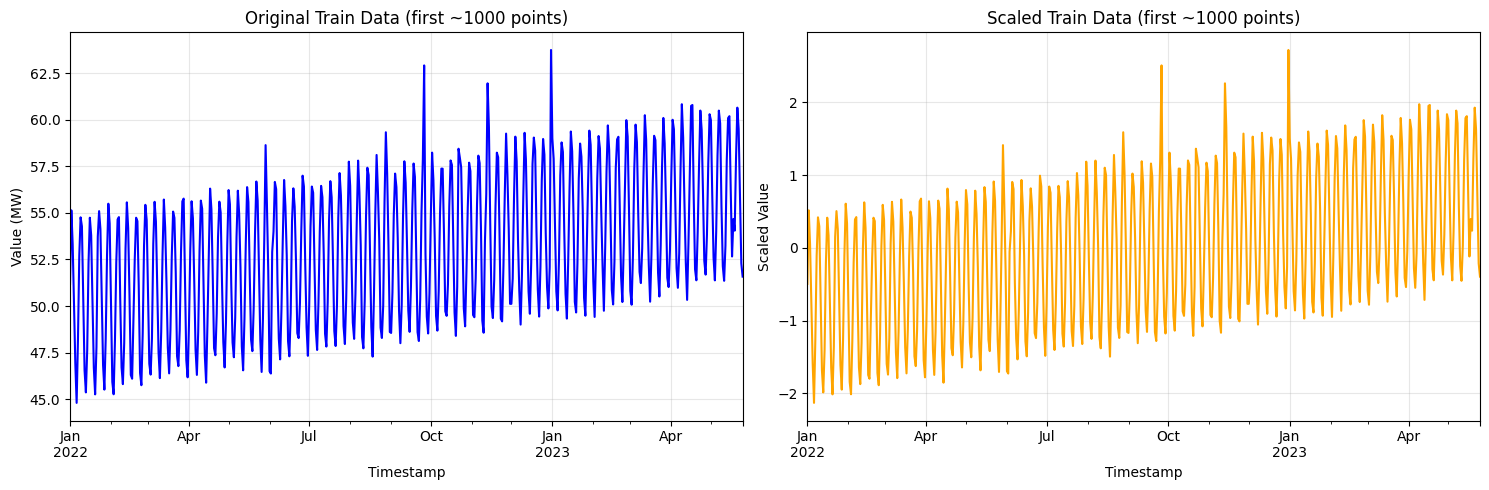

In [24]:
# Print scaling statistics
print_scaling_stats(train_s, val_s, test_s, "Z-Score")

# Visualize original vs scaled data in subplots
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 5))

# Original train data
train.iloc[:1000, 0].plot(ax=ax1, title='Original Train Data (first ~1000 points)', 
                          xlabel='Timestamp', ylabel='Value (MW)', color='blue')
ax1.grid(True, alpha=0.3)

# Scaled train data
train_s.iloc[:1000, 0].plot(ax=ax2, title='Scaled Train Data (first ~1000 points)', 
                            xlabel='Timestamp', ylabel='Scaled Value', color='orange')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Train-Validation-Test Split & Scaling</h2>

Apply what you've learned to the electricity dataset:
1. Split the resampled data into train, validation, and test sets using the Hold-Out Split method
2. Apply the most appropriate scaling method 
   - Try different scaling frequencies (e.g., zscore, MinMax)
   - Visualize random samples
3. Verify that scaling was properly applied without data leakage

This exercise will help you practice implementing a proper time series preprocessing pipeline.
</div>

In [25]:
# split the resampled electricity data in train validation test using the Hold-Out Split method
# 70% train, 15% val, 15% test

n_train_ex = int(len(resampled_exercise)*0.7)
n_val_ex = int(len(resampled_exercise)*0.15)

train_ex = resampled_exercise.iloc[:n_train_ex]
val_ex = resampled_exercise.iloc[n_train_ex:n_train_ex+n_val_ex]
test_ex = resampled_exercise.iloc[n_train_ex+n_val_ex:]

print('Split sizes:', len(train_ex), len(val_ex), len(test_ex))
print('Ranges:')
print('Train:', train_ex.index.min(), '→', train_ex.index.max())
print('Val  :', val_ex.index.min(),   '→', val_ex.index.max())
print('Test :', test_ex.index.min(),  '→', test_ex.index.max())



Split sizes: 767 164 166
Ranges:
Train: 2012-01-01 00:00:00 → 2014-02-05 00:00:00
Val  : 2014-02-06 00:00:00 → 2014-07-19 00:00:00
Test : 2014-07-20 00:00:00 → 2015-01-01 00:00:00



Robust Scaling Statistics:
Train - Mean: 0.472770, Std: 0.768595
Val   - Mean: 0.059740, Std: 0.375373
Test  - Mean: 0.446075, Std: 0.884235


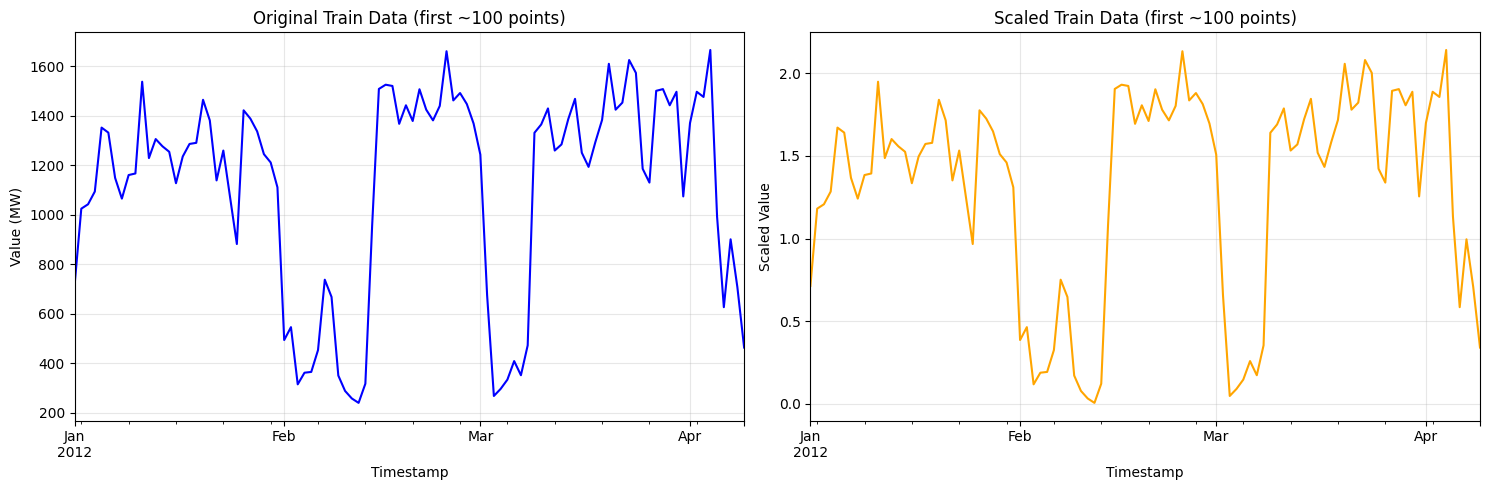

In [26]:
# - rescale the data using the most appropriate method

train_ex_s, val_ex_s, test_ex_s, SCALER_EX = scale_using_robust(train_ex, val_ex, test_ex)
print_scaling_stats(train_ex_s, val_ex_s, test_ex_s, "Robust")

# plot original vs scaled data in subplots
fig, ((ax1, ax2)) = plt.subplots(1, 2, figsize=(15, 5))
# Original train data
train_ex["MT_001"].iloc[:100].plot(ax=ax1, title='Original Train Data (first ~100 points)', 
                          xlabel='Timestamp', ylabel='Value (MW)', color='blue')
ax1.grid(True, alpha=0.3)
# Scaled train data
train_ex_s["MT_001"].iloc[:100].plot(ax=ax2, title='Scaled Train Data (first ~100 points)', 
                            xlabel='Timestamp', ylabel='Scaled Value', color='orange')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Creating Sliding Windows for Sequence Modeling

For supervised learning with time series, we need to transform our sequential data into input-output pairs using a sliding window approach.

### Key Parameters:
- **Window Size**: Number of past time steps to use as input features (e.g., 24 hours of history)
- **Forecast Horizon**: Number of future time steps to predict (e.g., next 6 hours)
- **Stride**: Step size between consecutive windows (smaller values create more overlapping samples)

This technique converts our time series into a format suitable for various modeling approaches, from traditional ML to deep learning architectures like RNNs, LSTMs, and Transformers.

In [27]:
# GUIDED: windowing utility
def make_windows(series, window_size, forecast_horizon, stride):
    """
    Convert a univariate or multivariate time series into (X, y) windows.
    X shape: (num_windows, window_size, num_features)
    y shape: (num_windows, forecast_horizon) if univariate target
    """
    values = series.values
    Xs, ys = [], []
    
    for i in range(0, len(values) - window_size - forecast_horizon + 1, stride):
        X_window = values[i:i + window_size]
        y_window = values[i + window_size:i + window_size + forecast_horizon]
        Xs.append(X_window)
        ys.append(y_window)
    
    return np.array(Xs), np.array(ys)

WINDOW_SIZE = 24   # past 24 hours
HORIZON = 6       # predict next 6 hours
STRIDE = 1

X_train, y_train = make_windows(train_s, WINDOW_SIZE, HORIZON, STRIDE)
X_val, y_val = make_windows(val_s, WINDOW_SIZE, HORIZON, STRIDE)
X_test, y_test = make_windows(test_s, WINDOW_SIZE, HORIZON, STRIDE)


Window shapes:
X_train: (481, 24, 1) (samples, window_size, features)
y_train: (481, 6, 1) (samples, forecast_horizon)
X_val: (80, 24, 1)
y_val: (80, 6, 1)
X_test: (82, 24, 1)
y_test: (82, 6, 1)


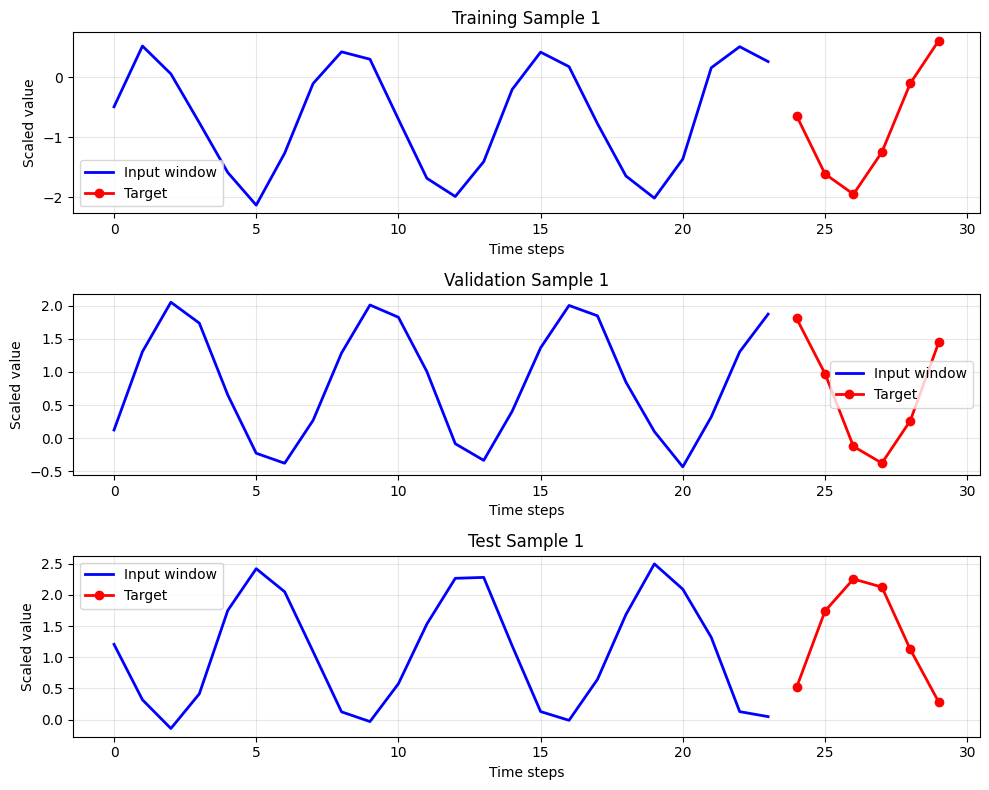

In [28]:
# Visualize the shapes and a sample of the windowed data
print(f"Window shapes:")
print(f"X_train: {X_train.shape} (samples, window_size, features)")
print(f"y_train: {y_train.shape} (samples, forecast_horizon)")
print(f"X_val: {X_val.shape}")
print(f"y_val: {y_val.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_test: {y_test.shape}")

# Plot a few windowed samples to verify correctness
fig, axes = plt.subplots(3, 1, figsize=(10, 8 ))

# Plot first training window
axes[0].plot(range(WINDOW_SIZE), X_train[0, :, 0], 'b-', label='Input window', linewidth=2)
axes[0].plot(range(WINDOW_SIZE, WINDOW_SIZE + HORIZON), y_train[0, :, 0], 'r-', label='Target', linewidth=2, marker='o')
axes[0].set_title('Training Sample 1')
axes[0].set_xlabel('Time steps')
axes[0].set_ylabel('Scaled value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# Plot validation window
axes[1].plot(range(WINDOW_SIZE), X_val[0, :, 0], 'b-', label='Input window', linewidth=2)
axes[1].plot(range(WINDOW_SIZE, WINDOW_SIZE + HORIZON), y_val[0, :, 0], 'r-', label='Target', linewidth=2, marker='o')
axes[1].set_title('Validation Sample 1')
axes[1].set_xlabel('Time steps')
axes[1].set_ylabel('Scaled value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot test window
axes[2].plot(range(WINDOW_SIZE), X_test[0, :, 0], 'b-', label='Input window', linewidth=2)
axes[2].plot(range(WINDOW_SIZE, WINDOW_SIZE + HORIZON), y_test[0, :, 0], 'r-', label='Target', linewidth=2, marker='o')
axes[2].set_title('Test Sample 1')
axes[2].set_xlabel('Time steps')
axes[2].set_ylabel('Scaled value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

<div style="background-color: #ffedcc; border-left: 6px solid #ff7518; padding: 10px; margin-bottom: 10px;">
<h2>📝 Exercise: Creating Sliding Windows</h2>

Apply the windowing technique to the preprocessed electricity dataset:
1. Create input-output window pairs from the train, validation, and test sets
2. Experiment with different window sizes and forecast horizons
   - Test different window sizes (e.g., 12, 24, 48)
   - Adjust the forecast horizon (e.g., 1, 3, 6)

3. Visualize sample windows to ensure they're constructed correctly

This exercise will help you understand how different window parameters affect your model inputs and prediction targets.
</div>

Window shapes:
X_train: (738, 24, 100) (samples, window_size, features)
y_train: (738, 6, 100) (samples, forecast_horizon)
X_val: (135, 24, 100)
y_val: (135, 6, 100)
X_test: (137, 24, 100)
y_test: (137, 6, 100)


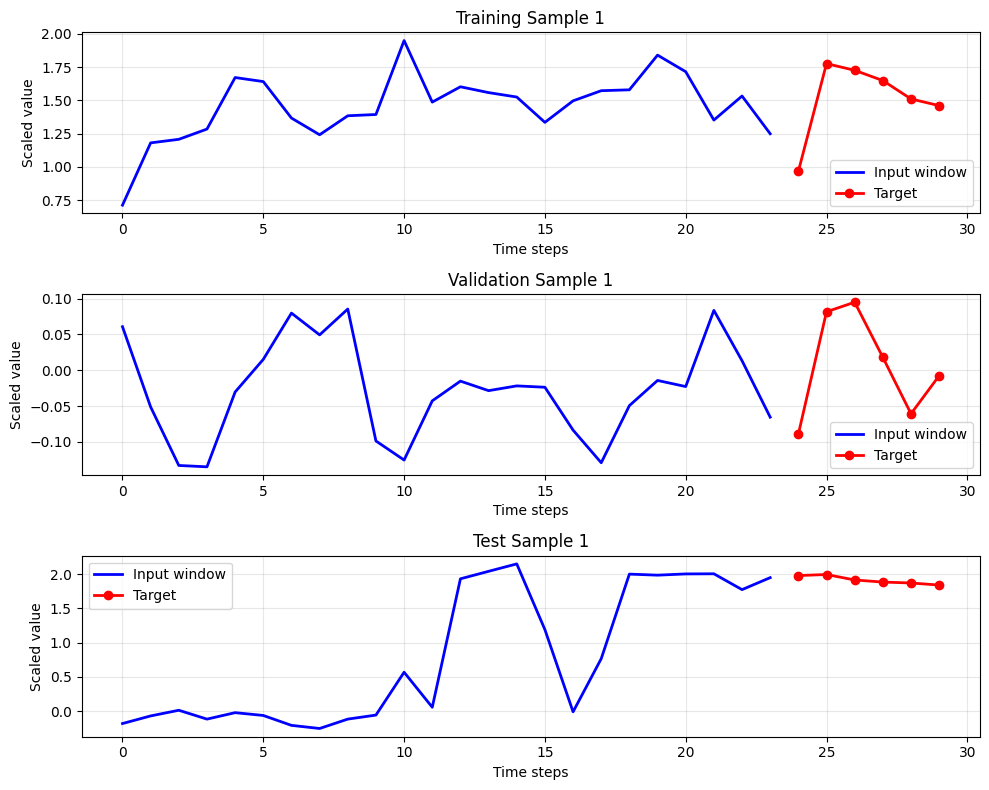

In [29]:
# create windows for the exercise dataset

WINDOW_SIZE = 24   # past 24 hours
HORIZON = 6       # predict next 6 hours
STRIDE = 1

X_train_ex, y_train_ex = make_windows(train_ex_s, WINDOW_SIZE, HORIZON, STRIDE)
X_val_ex, y_val_ex = make_windows(val_ex_s, WINDOW_SIZE, HORIZON, STRIDE)
X_test_ex, y_test_ex = make_windows(test_ex_s, WINDOW_SIZE, HORIZON, STRIDE)

# Visualize the shapes and a sample of the windowed data
print(f"Window shapes:")
print(f"X_train: {X_train_ex.shape} (samples, window_size, features)")
print(f"y_train: {y_train_ex.shape} (samples, forecast_horizon)")
print(f"X_val: {X_val_ex.shape}")
print(f"y_val: {y_val_ex.shape}")
print(f"X_test: {X_test_ex.shape}")
print(f"y_test: {y_test_ex.shape}")

# Plot a few windowed samples to verify correctness
fig, axes = plt.subplots(3, 1, figsize=(10, 8 ))
# Plot first training window
axes[0].plot(range(WINDOW_SIZE), X_train_ex[0, :, 0], 'b-', label='Input window', linewidth=2)
axes[0].plot(range(WINDOW_SIZE, WINDOW_SIZE + HORIZON), y_train_ex[0, :, 0], 'r-', label='Target', linewidth=2, marker='o')
axes[0].set_title('Training Sample 1')
axes[0].set_xlabel('Time steps')
axes[0].set_ylabel('Scaled value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
# Plot validation window
axes[1].plot(range(WINDOW_SIZE), X_val_ex[0, :, 0], 'b-', label='Input window', linewidth=2)
axes[1].plot(range(WINDOW_SIZE, WINDOW_SIZE + HORIZON), y_val_ex[0, :, 0], 'r-', label='Target', linewidth=2, marker='o')
axes[1].set_title('Validation Sample 1')
axes[1].set_xlabel('Time steps')
axes[1].set_ylabel('Scaled value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
# Plot test window
axes[2].plot(range(WINDOW_SIZE), X_test_ex[0, :, 0], 'b-', label='Input window', linewidth=2)
axes[2].plot(range(WINDOW_SIZE, WINDOW_SIZE + HORIZON), y_test_ex[0, :, 0], 'r-', label='Target', linewidth=2, marker='o')
axes[2].set_title('Test Sample 1')
axes[2].set_xlabel('Time steps')
axes[2].set_ylabel('Scaled value')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## ✅ Summary

### What You've Accomplished:
- Loaded and performed quality checks on time series data
- Implemented strategies for handling missing values and resampling
- Applied proper scaling techniques while avoiding data leakage
- Created time-aware train/validation/test splits
- Generated sliding windows for supervised learning approaches

These preprocessing steps are crucial for achieving good performance with any time series forecasting model.